In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.colors
import matplotlib.ticker as ticker

### Define Color Map

In [2]:
# 'tab20' colormap, converting to hex and optionally removing a specific color
tab20_cmap = get_cmap('tab20')
colors_hex_list_20 = [matplotlib.colors.to_hex(c) for c in tab20_cmap.colors]
# remove a specific color, make sure it's in the list before removing
colors_hex_list_20.remove('#d62728')
colors_hex_list_20.remove('#ff9896')
colors_hex_list_20.remove('#7f7f7f')
colors_hex_list_20.remove('#c7c7c7')
# for color_hex in colors_hex_list_20:
#     print(color_hex)

# 'tab10' colormap, converting to hex and optionally removing a specific color
tab10_cmap = get_cmap('tab10')
colors_hex_list_10 = [matplotlib.colors.to_hex(c) for c in tab10_cmap.colors]
# remove a specific color, make sure it's in the list before removing
colors_hex_list_10.remove('#d62728')
# colors_hex_list_10.remove('#7f7f7f')
# for color_hex in colors_hex_list_10:
#     print(color_hex)

/tmp/ipykernel_19958/1985473031.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab20_cmap = get_cmap('tab20')
/tmp/ipykernel_19958/1985473031.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab10_cmap = get_cmap('tab10')


### Architectures

In [3]:
# custom order
custom_order = ["Agent-OM", "LLM-Only", "LLM-with-Context"]
custom_order_index = {name: index for index, name in enumerate(custom_order)}

In [4]:
# set new matcher
new_matcher = "Agent-OM"
new_matcher_color = "#d62728"

### LLMs

In [5]:
def generate_llm_evaluation(alignment, csv_path):
    df = pd.read_csv(csv_path)
    # filter rows where the "Alignment" column ends with "llm_with_agent"
    filtered_df = df[
        df['Alignment'].str.startswith(alignment, na=False) &
        df['Alignment'].str.contains('llm_with_agent', na=False)
    ].copy()
    # add a new column "Name" with values from the "LLM" column
    filtered_df.loc[:, 'Name'] = filtered_df['LLM'].replace({
        'gpt-4o-2024-05-13': 'gpt-4o',
        'gpt-4o-mini-2024-07-18': 'gpt-4o-mini',
        'claude-3-sonnet-20240229': 'claude-3-sonnet',
        'claude-3-haiku-20240307': 'claude-3-haiku',
        'mistral-small:22b': 'mistral-small',
        'mistral-nemo:12b': 'mistral-nemo',
        'llama3:8b': 'llama-3-8b',
        'llama3.1:8b': 'llama-3.1-8b',
        'qwen2:7b': 'qwen-2-7b',
        'qwen2.5:7b': 'qwen-2.5-7b',
        'gemma2:9b': 'gemma-2-9b',
        'glm4:9b': 'glm-4-9b',
        'hermes3:8b': 'hermes-3-8b',
        'yi:9b': 'yi-9b',
    })
    # drop the "Alignment" column
    filtered_df = filtered_df.drop(columns=['LLM'])
    # save the modified DataFrame to a new CSV file
    return filtered_df

In [6]:
def draw_and_save(alignment, title_left, title_right, overall_title, output_png, color_selection,
                  min_f1_1, max_f1_1, num_f1_1, min_f1_2, max_f1_2, num_f1_2):

    # load data
    df1 = generate_llm_evaluation(alignment, 'result-normal.csv')
    df2 = generate_llm_evaluation(alignment, 'result-lite.csv')

    df1['Precision'] = df1['Precision'] / 100
    df1['Recall'] = df1['Recall'] / 100
    df1 = df1.iloc[df1.apply(custom_sort, axis=1).argsort()]

    df2['Precision'] = df2['Precision'] / 100
    df2['Recall'] = df2['Recall'] / 100
    df2 = df2.iloc[df2.apply(custom_sort, axis=1).argsort()]
    
    # combine unique model names from both datasets
    combined_names = pd.concat([df1['Name'], df2['Name']]).unique().tolist()

    # set marker size
    marker_size = 50
    new_marker_size = 50

    color_map_updated = {}
    # loop through combined_names to assign colors from colors_hex_list_20, except for "Agent-OM"
    for i, name in enumerate(combined_names):
        red_color = "#d62728"  # Define the red color hex code
        # Assign the red color to the first item in the list
        color_map_updated[combined_names[0]] = red_color
        if color_selection == "tab10":
            color_map_updated[name] = colors_hex_list_10[i-1 % len(colors_hex_list_10)]
        if color_selection == "tab20":
            color_map_updated[name] = colors_hex_list_20[i-1 % len(colors_hex_list_20)]

    # create the plot with updated color map
    fig, axs = plt.subplots(1, 2, figsize=(7.5, 3))

    # turn off the grid
    axs[0].grid(False)
    axs[1].grid(False)

    # set specific values for x-axis and y-axis ticks
    tick_values_1 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    axs[0].set_xticks(tick_values_1)
    axs[0].set_yticks(tick_values_1)
    tick_values_2 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    axs[1].set_xticks(tick_values_2)
    axs[1].set_yticks(tick_values_2)

    # adjust font size for x-axis and y-axis labels
    for ax in axs:
        ax.tick_params(axis='x', labelsize=10)  # Adjust x-axis label font size
        ax.tick_params(axis='y', labelsize=10)  # Adjust y-axis label font size

    # adjust the spacing between the subplots
    fig.subplots_adjust(wspace=0.3)  # Increase the space between subplots
    # adjust the subplot parameters to give some space for the legends
    plt.subplots_adjust(top=0.75)

    # initialize the zorder value
    initial_zorder = 50
    
    for name, group in df1.groupby('Name'):
        if name in API_models:
            axs[0].scatter(group['Recall'], group['Precision'], label=name, color=color_map_updated[name],
                           s=new_marker_size, marker='^', zorder=99)
        else:
            axs[0].scatter(group['Recall'], group['Precision'], label=name, color=color_map_updated[name],
                      s=marker_size, marker='^', zorder=initial_zorder)
            initial_zorder -= 1
        # calculate and plot the iso-F1 curves
        f1_levels = np.linspace(0.1, max_f1_1, num=num_f1_1)
        for f1 in f1_levels:
            x = np.linspace(0.001, 1.1, 1100)
            y = f1 * x / (2 * x - f1)
            valid_idx = np.where(y >= 0)  # valid indices where y is non-negative
            axs[0].plot(x[valid_idx], y[valid_idx], color='grey', alpha=1, linestyle='--', zorder=1)
            axs[0].annotate('F1={0:0.2f}'.format(f1), xy=(x[-10], y[-10]), textcoords="offset points", 
                            xytext=(25, -3), ha='center')

    axs[0].set_title(title_left)
    axs[0].set_xlim([min_f1_1, 1.1])
    axs[0].set_ylim([min_f1_1, 1.1])
    axs[0].set_xlabel('Recall', fontsize=10)
    axs[0].set_ylabel('Precision', fontsize=10)

    # initialize the zorder value
    initial_zorder = 50

    for name, group in df2.groupby('Name'):
        if name in API_models:
            axs[1].scatter(group['Recall'], group['Precision'], label=name, color=color_map_updated[name],
                           s=new_marker_size, marker='^', zorder=99)
        else:   
            axs[1].scatter(group['Recall'], group['Precision'], label=name, color=color_map_updated[name],
                           s=marker_size, marker='^', zorder=initial_zorder)
            initial_zorder -= 1
        # calculate and plot the iso-F1 curves
        f1_levels = np.linspace(0.1, max_f1_2, num=num_f1_2)
        for f1 in f1_levels:
            x = np.linspace(0.001, 1.1, 1100)
            y = f1 * x / (2 * x - f1)
            valid_idx = np.where(y >= 0)  # valid indices where y is non-negative
            axs[1].plot(x[valid_idx], y[valid_idx], color='grey', alpha=1, linestyle='--', zorder=1)
            axs[1].annotate('F1={0:0.2f}'.format(f1), xy=(x[-10], y[-10]), textcoords="offset points", 
                            xytext=(25, -3), ha='center')

    axs[1].set_title(title_right)
    axs[1].set_xlim([min_f1_2, 1.1])
    axs[1].set_ylim([min_f1_2, 1.1])
    axs[1].set_xlabel('Recall', fontsize=10)
    axs[1].set_ylabel('Precision', fontsize=10)

    # axs[0].set_ylabel('Scores')
    # for ax in axs:
    #     ax.set_xlabel('Metrics')
    #     ax.grid(True)

    # initialize the list before using it
    handles = []
    # create custom handles for the unified legend with colors
    for i, name in enumerate(combined_names):
        if name in API_models:
            handles += [plt.Line2D([0], [0], marker='^', linestyle='None', markersize=10, label=combined_names[0], color=color_map_updated[combined_names[i]])]
        else:
            handles += [plt.Line2D([0], [0], marker='o', linestyle='None', markersize=10, label=combined_names[0], color=color_map_updated[combined_names[i]])]
    
    # handles = [plt.Line2D([0], [0], marker='^', linestyle='None', markersize=10, label=name, 
    #            color=color_map_updated[name]) for name in combined_names]

    # add the legend
    # create a legend for 'Agent-OM', aligned to the left above the figure
    # legend_a = fig.legend(handles=[handles[0]], loc='upper left', bbox_to_anchor=(0.02, 0.05), ncol=1, frameon=False)
    # create a second legend for the rest, aligned to the right above the figure
    # fig.legend(handles=handles[1:], loc='upper left', bbox_to_anchor=(0.2, 0.05), 
    #           ncol=4, frameon=True, labelspacing=0.5, columnspacing=0.5)
    # fig.legend(handles, combined_names, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
    #             ncol=5, frameon=True, labelspacing=0.5, columnspacing=0.5)

    # Add overall title
    fig.text(0.5, 0.01, overall_title, ha='center', fontsize=12)

    # adjust the plot
    plt.tight_layout()
    # save the plot
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    # show the plot
    plt.show()

In [7]:
# define the custom order
custom_order = ['gpt-4o', 'gpt-4o-mini', 
                'claude-3-sonnet','claude-3-haiku',
                'llama-3-8b', 'llama-3.1-8b',
                'qwen-2-7b', 'qwen-2.5-7b',
                'gemma-2-9b', 'glm-4-9b']
# create a dictionary to map names to their custom order
order_dict = {name.lower(): index for index, name in enumerate(custom_order)}

# define the custom sort function
def custom_sort(row):
    name = row['Name'].lower()
    # return the index of the name in the custom order if it exists
    # otherwise return a large number to push it to the end
    return order_dict.get(name, float('inf'))

In [8]:
# set new matcher
API_models = ['gpt-4o', 'gpt-4o-mini', 'claude-3-sonnet','claude-3-haiku']
red_color = ""

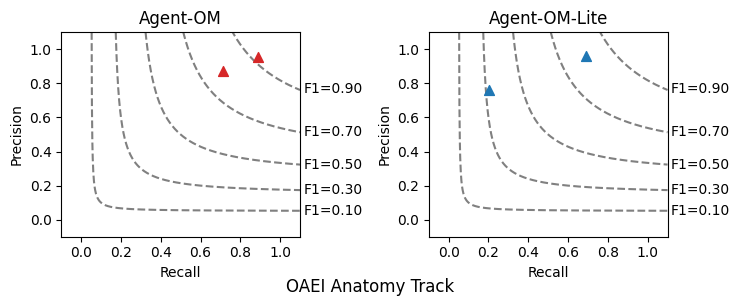

In [9]:
draw_and_save('anatomy',
              "Agent-OM", "Agent-OM-Lite", 
              "OAEI Anatomy Track", "anatomy.png", "tab10", 
              -0.1, 0.9, 5, -0.1, 0.9, 5)

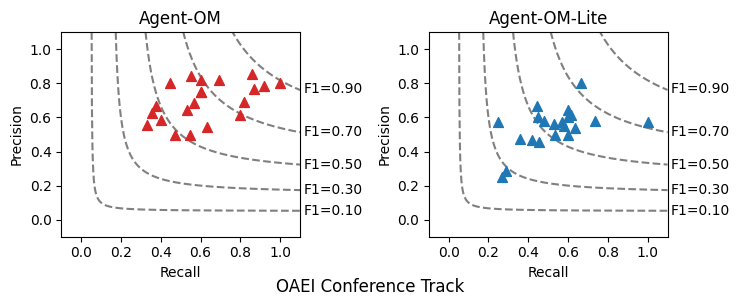

In [10]:
draw_and_save('conference',
              "Agent-OM", "Agent-OM-Lite", 
              "OAEI Conference Track", "conference.png", "tab10", 
              -0.1, 0.9, 5, -0.1, 0.9, 5)

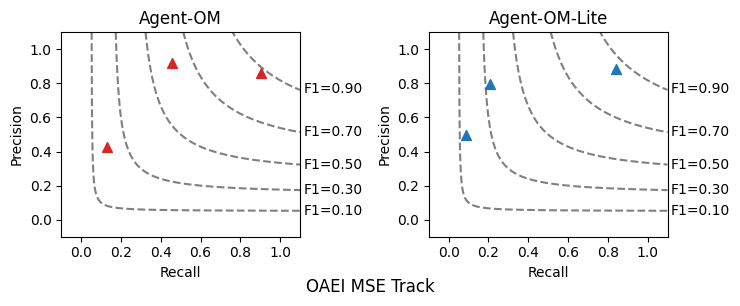

In [11]:
draw_and_save('mse',
              "Agent-OM", "Agent-OM-Lite", 
              "OAEI MSE Track", "mse.png", "tab10", 
              -0.1, 0.9, 5, -0.1, 0.9, 5)